In [439]:
from matplotlib.animation import FuncAnimation
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

plt.rcParams.update({'font.size': 16, 'figure.figsize': (8, 8)})
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",   # closest math font to Times
})

In [440]:
G   = 4 * np.pi**2   # AU^3 / (M_sun * yr^2)
M   = 1.0            # Solar mass
GM  = G * M
M_J = 9.548e-4       # Jupiter mass in solar masses
GM_J = G * M_J

In [441]:
def accel_voyager(xv, yv, xj, yj):
    # From Sun
    rv  = np.sqrt(xv**2 + yv**2)
    axs = -GM   * xv / rv**3
    ays = -GM   * yv / rv**3
    # From Jupiter
    dxj = xv - xj
    dyj = yv - yj
    rj  = np.sqrt(dxj**2 + dyj**2)
    axj = -GM_J * dxj / rj**3
    ayj = -GM_J * dyj / rj**3
    return axs + axj, ays + ayj

def accel_jupiter(xj, yj):
    rj  = np.sqrt(xj**2 + yj**2)
    ax = -GM * xj / rj**3
    ay = -GM * yj / rj**3
    return ax,ay

In [442]:
# Leapfrog for 3-body system 
def leapfrog_3body(xv0, yv0, vxv0, vyv0,#voyager initial values
                   xj0, yj0, vxj0, vyj0, #jupiter initial values
                   h, N):
    xv  = np.zeros(N+1);  yv  = np.zeros(N+1)
    vxv = np.zeros(N+1);  vyv = np.zeros(N+1)
    xj  = np.zeros(N+1);  yj  = np.zeros(N+1)
    vxj = np.zeros(N+1);  vyj = np.zeros(N+1)

    xv[0], yv[0]   = xv0, yv0
    vxv[0], vyv[0] = vxv0, vyv0
    xj[0], yj[0]   = xj0, yj0
    vxj[0], vyj[0] = vxj0, vyj0

    # Initial accelerations
    axv, ayv = accel_voyager(xv[0], yv[0], xj[0], yj[0])
    axj, ayj = accel_jupiter(xj[0], yj[0])

    for i in range(N):
       
        vxv_half = vxv[i] + 0.5 * axv * h
        vyv_half = vyv[i] + 0.5 * ayv * h
        vxj_half = vxj[i] + 0.5 * axj * h
        vyj_half = vyj[i] + 0.5 * ayj * h

        
        xv[i+1] = xv[i] + vxv_half * h
        yv[i+1] = yv[i] + vyv_half * h
        xj[i+1] = xj[i] + vxj_half * h
        yj[i+1] = yj[i] + vyj_half * h

        
        axv, ayv = accel_voyager(xv[i+1], yv[i+1], xj[i+1], yj[i+1])
        axj, ayj = accel_jupiter(xj[i+1], yj[i+1])

        
        vxv[i+1] = vxv_half + 0.5 * axv * h
        vyv[i+1] = vyv_half + 0.5 * ayv * h
        vxj[i+1] = vxj_half + 0.5 * axj * h
        vyj[i+1] = vyj_half + 0.5 * ayj * h

    return xv, yv, vxv, vyv, xj, yj, vxj, vyj

In [443]:
r_E = 1.0
r_J = 5.2

# Hohmann transfer orbit parameters
a_transfer = (rE + rJ) / 2        

# Transfer time (half-period of the ellipse)
t_transfer = np.pi * np.sqrt(a_transfer**3 / GM)

# Voyager launch speed at perihelion (vis-viva equation)
v_perihelion = np.sqrt(GM * (2/rE - 1/a_transfer))

# Jupiter's angular velocity
T_J = 2 * np.pi * np.sqrt(rJ**3 / GM)
omega_J = 2 * np.pi / T_J

# Jupiter's initial angle: must arrive at angle π when Voyager does
theta_J0 = np.pi - omega_J * t_transfer


xv0, yv0   =  0.0, -rE          # Voyager on -y axis
vxv0, vyv0 =  v_perihelion, 0.0  # launches in +x direction

# Jupiter 
phi = +0.05  

theta_J0   =  np.pi - omega_J * t_transfer + phi - np.pi/2  # Jupiter in 1st quadrant

xj0  =  rJ * np.cos(theta_J0)
yj0  =  rJ * np.sin(theta_J0)
vj   =  np.sqrt(GM / rJ)
vxj0 = -vj * np.sin(theta_J0)
vyj0 =  vj * np.cos(theta_J0)

print(f"Transfer time   : {T_h:.3f} yr  ({T_h*12:.2f} months)")
print(f"Voyager launch speed: {v_perihelion * 4.74047:.2f} km/s")
print(f"Jupiter angle   : {np.degrees(phi_J0):.2f} deg")
print(f"Jupiter start   : ({xj0:.2f}, {yj0:.2f}) AU")
print(f"Encounter at    : (0.00, {r_J:.2f}) AU")


Transfer time   : 2.729 yr  (32.75 months)
Voyager launch speed: 38.58 km/s
Jupiter angle   : 11.15 deg
Jupiter start   : (5.12, 0.90) AU
Encounter at    : (0.00, 5.20) AU


In [444]:
h = 0.001          # yr
N = 4000           # 5 years total

xv, yv, vxv, vyv, xj, yj, vxj, vyj = leapfrog_3body(
    xv0, yv0, vxv0, vyv0,
    xj0, yj0, vxj0, vyj0,
    h, N
)

In [445]:
# Compute speed
speed_v = np.sqrt(vxv**2 + vyv**2)
speed_v_kms = speed_v * 4.74047   # convert AU/yr to km/s

# Time array — always built from actual array length
t_mon = np.arange(len(speed_v_kms)) * h * 12

# Distance between Voyager and Jupiter
dist_vj = np.sqrt((xv - xj)**2 + (yv - yj)**2)
flyby_idx = np.argmin(dist_vj)

print(f"Flyby at t = {t_mon[flyby_idx]:.1f} months")
print(f"Closest distance = {dist_vj[flyby_idx]:.4f} AU")

Flyby at t = 29.3 months
Closest distance = 0.0031 AU


In [446]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-7, 7)
ax.set_ylim(-2, 12)
ax.set_aspect('equal')
ax.set_xlabel('x [AU]')
ax.set_ylabel('y [AU]')
ax.set_title('Voyager 2 Gravity Assist around Jupiter')

# Sun
sun = ax.scatter(0, 0, color='orange', s=200, label='Sun', zorder=5)

# Orbit lines
voyager_line, = ax.plot([], [], 'b-', lw=1)
jupiter_line, = ax.plot([], [], 'r-', lw=1)

# Jupiter's circular orbit (dashed)
theta_orbit = np.linspace(0, 2*np.pi, 500)
ax.plot(rJ * np.cos(theta_orbit), rJ * np.sin(theta_orbit), 'r--', lw=1, alpha=0.4,label= "Jupiter Orbit")

# Moving dots
voyager_dot, = ax.plot([], [], 'bo', markersize=5, label='Voyager 2', zorder=10)
jupiter_dot, = ax.plot([], [], 'ro', markersize=8, label='Jupiter', zorder=10)

# Info text
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)
speed_text = ax.text(0.02, 0.90, '', transform=ax.transAxes)

ax.legend(loc='upper right',fontsize=12)

def init():
    voyager_line.set_data([], [])
    jupiter_line.set_data([], [])
    voyager_dot.set_data([], [])
    jupiter_dot.set_data([], [])
    time_text.set_text('')
    speed_text.set_text('')
    return voyager_line, jupiter_line, voyager_dot, jupiter_dot, time_text, speed_text

points_per_frame = 25  # controls speed of animation

def update(i):
    idx = i * points_per_frame
    if idx >= len(xv): idx = len(xv) - 1

    voyager_line.set_data(xv[:idx], yv[:idx])
    voyager_dot.set_data([xv[idx]], [yv[idx]])

    # jupiter_line removed — orbit already shown as dashed circle
    jupiter_dot.set_data([xj[idx]], [yj[idx]])

    time_text.set_text(f"Time = {idx*h*12:.1f} months")
    speed_text.set_text(f"v = {speed_v_kms[idx]:.2f} km/s")

    return voyager_line, jupiter_line, voyager_dot, jupiter_dot, time_text, speed_text

ani = animation.FuncAnimation(fig, update, frames=len(xv)//points_per_frame, 
                              init_func=init, blit=False, interval=50, repeat=False)

plt.close()
plt.tight_layout()
display(HTML(ani.to_html5_video()))

<Figure size 800x800 with 0 Axes>

  Closest approach  : t = 29.3 months
  Closest distance  : 0.0031 AU
                    = 471056 km
  Speed BEFORE flyby: 7.62 km/s
  Speed AT closest  : 20.53 km/s
  Speed AFTER flyby : 19.27 km/s
  Speed gained      : 11.65 km/s


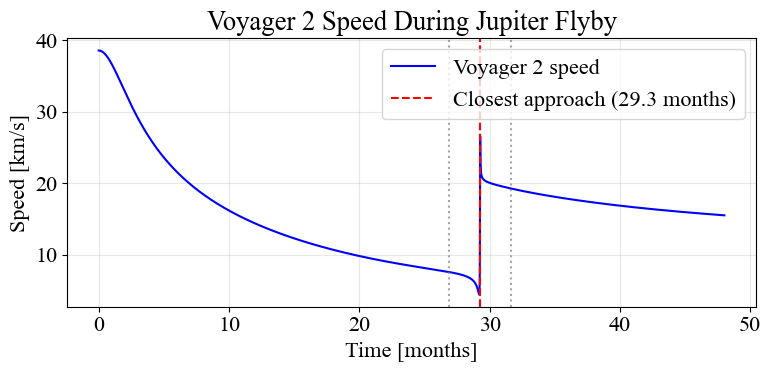

In [447]:
t_yr  = np.arange(N+1) * h          # time array in years
t_mon = np.arange(len(speed_v_kms)) * h * 12
# Closest approach
dist_vj   = np.sqrt((xv - xj)**2 + (yv - yj)**2)
flyby_idx = np.argmin(dist_vj)

print("=" * 45)
print(f"  Closest approach  : t = {t_mon[flyby_idx]:.1f} months")
print(f"  Closest distance  : {dist_vj[flyby_idx]:.4f} AU")
print(f"                    = {dist_vj[flyby_idx]*1.496e8:.0f} km")
print(f"  Speed BEFORE flyby: {speed_v_kms[flyby_idx-window]:.2f} km/s")
print(f"  Speed AT closest  : {speed_v_kms[flyby_idx]:.2f} km/s")
print(f"  Speed AFTER flyby : {speed_v_kms[flyby_idx+window]:.2f} km/s")
print(f"  Speed gained      : {speed_v_kms[flyby_idx+window] - speed_v_kms[flyby_idx-window]:.2f} km/s")
print("=" * 45)

# Speed vs time plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_mon, speed_v_kms, 'b-', lw=1.5, label="Voyager 2 speed")
ax.axvline(t_mon[flyby_idx], color='r', ls='--', label=f"Closest approach ({t_mon[flyby_idx]:.1f} months)")
ax.axvline(t_mon[flyby_idx - window], color='gray', ls=':', alpha=0.7)
ax.axvline(t_mon[flyby_idx + window], color='gray', ls=':', alpha=0.7)
ax.set_xlabel("Time [months]")
ax.set_ylabel("Speed [km/s]")
ax.set_title("Voyager 2 Speed During Jupiter Flyby")
ax.legend()
plt.tight_layout()
plt.savefig("voyager_speed.pdf", dpi=150)
plt.show()